<a href="https://colab.research.google.com/github/predicting-pregnancy-success/pregnancy-ml-models/blob/main/%E1%84%82%E1%85%A1%E1%86%AB%E1%84%8B%E1%85%B5%E1%86%B7%E1%84%92%E1%85%AA%E1%86%AB%E1%84%8C%E1%85%A1_%E1%84%8B%E1%85%B5%E1%86%B7%E1%84%89%E1%85%B5%E1%86%AB%E1%84%80%E1%85%A1%E1%84%82%E1%85%B3%E1%86%BC_%E1%84%8B%E1%85%A8%E1%84%8E%E1%85%B3%E1%86%A8_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import random
import os

# 한글 폰트 설치 및 설정
!apt-get -qq -y install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 폰트 경로 설정
fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_name = fm.FontProperties(fname=fontpath).get_name()
plt.rc('font', family=font_name)
fm._rebuild() if hasattr(fm, '_rebuild') else None

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, accuracy_score

import seaborn as sns
sns.set_style('whitegrid')
# Seaborn 폰트 설정
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

In [2]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(42) # Seed 고정

In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("### Train Data Head ###")
display(train.head())
print("\n### Train Data Info ###")
train.info()

### Train Data Head ###


,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0
3,TRAIN_000003,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
4,TRAIN_000004,TRVNRY,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0



### Train Data Info ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256351 entries, 0 to 256350
Data columns (total 69 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     256351 non-null  object 
 1   시술 시기 코드               256351 non-null  object 
 2   시술 당시 나이               256351 non-null  object 
 3   임신 시도 또는 마지막 임신 경과 연수  9370 non-null    float64
 4   시술 유형                  256351 non-null  object 
 5   특정 시술 유형               256349 non-null  object 
 6   배란 자극 여부               256351 non-null  int64  
 7   배란 유도 유형               256351 non-null  object 
 8   단일 배아 이식 여부            250060 non-null  float64
 9   착상 전 유전 검사 사용 여부       2718 non-null    float64
 10  착상 전 유전 진단 사용 여부       250060 non-null  float64
 11  남성 주 불임 원인             256351 non-null  int64  
 12  남성 부 불임 원인             256351 non-null  int64  
 13  여성 주 불임 원인             256351 non-null  int64  
 14  여성 부 불임 원인 

In [4]:
print("### Train Data Missing Values ###")
display(train.isnull().sum())

### Train Data Missing Values ###


,0
ID,0
시술 시기 코드,0
시술 당시 나이,0
임신 시도 또는 마지막 임신 경과 연수,246981
시술 유형,0
...,...
난자 해동 경과일,254915
난자 혼합 경과일,53735
배아 이식 경과일,43566
배아 해동 경과일,215982


In [5]:
print("### Train Data Descriptive Statistics ###")
display(train.describe())

### Train Data Descriptive Statistics ###


,임신 시도 또는 마지막 임신 경과 연수,배란 자극 여부,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,착상 전 유전 진단 사용 여부,남성 주 불임 원인,남성 부 불임 원인,여성 주 불임 원인,여성 부 불임 원인,부부 주 불임 원인,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
count,9370.000000,256351.000000,250060.000000,2718.0,250060.000000,256351.000000,256351.000000,256351.000000,256351.000000,256351.000000,...,250060.000000,250060.000000,2179.0,1929.0,198863.0,1436.000000,202616.000000,212785.000000,40369.000000,256351.000000
mean,9.270651,0.771286,0.233476,1.0,0.012781,0.028516,0.013115,0.030724,0.012432,0.033068,...,0.009830,0.004195,1.0,1.0,0.0,0.001393,0.005385,3.254741,0.045629,0.258349
std,3.550313,0.420005,0.423043,0.0,0.112328,0.166441,0.113767,0.172568,0.110805,0.178814,...,0.098656,0.064633,0.0,0.0,0.0,0.037307,0.111504,1.715697,0.418672,0.437728
min,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,1.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,2.000000,0.000000,0.000000
50%,9.000000,1.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,3.000000,0.000000,0.000000
75%,11.000000,1.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,5.000000,0.000000,1.000000
max,20.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.0,1.0,0.0,1.000000,7.000000,7.000000,7.000000,1.000000


In [6]:
train_copy = train.copy()
test_copy = test.copy()

# '임신 성공 여부' 결측치 행 제거
train_copy = train_copy.dropna(subset=['임신 성공 여부'])

# 1. 파생 변수 생성 함수
def calculate_ratio(df, numerator, denominator, new_col):
    # 문자열 'Unknown' 등을 수치로 변환 (변환 불가 시 NaN)
    num = pd.to_numeric(df[numerator], errors='coerce').fillna(0)
    den = pd.to_numeric(df[denominator], errors='coerce').fillna(0)
    df[new_col] = np.where(den > 0, num / den, 0)
    return df

# 파생 변수 적용
for df in [train_copy, test_copy]:
    # 전체 출산 성공률
    df = calculate_ratio(df, '총 출산 횟수', '총 임신 횟수', '전체_출산_성공률')
    # IVF 성공률
    df = calculate_ratio(df, 'IVF 출산 횟수', 'IVF 임신 횟수', 'IVF_출산_성공률')
    # 배아 이식 효율
    df = calculate_ratio(df, '이식된 배아 수', '총 생성 배아 수', '배아_이식_효율')

# 결측치가 많은 컬럼 삭제
train_copy = train_copy.drop(columns=['임신 시도 또는 마지막 임신 경과 연수'])
test_copy = test_copy.drop(columns=['임신 시도 또는 마지막 임신 경과 연수'])

# 범주형/숫자형 결측치 처리
object_cols = [
    '특정 시술 유형', '배아 생성 주요 이유', '총 시술 횟수', '클리닉 내 총 시술 횟수',
    'IVF 시술 횟수', 'DI 시술 횟수', '총 임신 횟수', 'IVF 임신 횟수', 'DI 임신 횟수',
    '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수', '난자 출처', '정자 출처',
    '난자 기증자 나이', '정자 기증자 나이'
]

number_cols = [
    '단일 배아 이식 여부', '착상 전 유전 검사 사용 여부', '착상 전 유전 진단 사용 여부',
    '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태', '총 생성 배아 수',
    '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '이식된 배아 수',
    '미세주입 배아 이식 수', '저장된 배아 수', '미세주입 후 저장된 배아 수',
    '해동된 배아 수', '해동 난자 수', '수집된 신선 난자 수', '저장된 신선 난자 수',
    '혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수',
    '동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부',
    '대리모 여부', 'PGD 시술 여부', 'PGS 시술 여부', '난자 채취 경과일',
    '난자 해동 경과일', '난자 혼합 경과일', '배아 이식 경과일', '배아 해동 경과일',
    '전체_출산_성공률', 'IVF_출산_성공률', '배아_이식_효율' # 파생 변수 추가
]

train_copy[object_cols] = train_copy[object_cols].fillna('Unknown')
test_copy[object_cols] = test_copy[object_cols].fillna('Unknown')
train_copy[number_cols] = train_copy[number_cols].fillna(0)
test_copy[number_cols] = test_copy[number_cols].fillna(0)

print("### 파생 변수 포함 결측치 처리 완료 ###")
display(train_copy[['전체_출산_성공률', 'IVF_출산_성공률', '배아_이식_효율']].head())

### 파생 변수 포함 결측치 처리 완료 ###


,전체_출산_성공률,IVF_출산_성공률,배아_이식_효율
0,0.0,0.0,0.500000
1,0.0,0.0,0.000000
2,0.0,0.0,0.400000
3,0.0,0.0,0.000000
4,0.0,0.0,0.333333


In [7]:
age_mapping = {
    '만18-34세': 26,
    '만35-37세': 36,
    '만38-39세': 38.5,
    '만38-40세': 39,
    '만41-42세': 41.5,
    '만43-44세': 43.5,
    '만45-50세': 47.5
}

# .map()을 사용하여 매핑을 적용하고, 매핑되지 않은 값은 NaN이 됩니다.
train_copy['시술 당시 나이_num'] = train_copy['시술 당시 나이'].map(age_mapping)
test_copy['시술 당시 나이_num'] = test_copy['시술 당시 나이'].map(age_mapping)

# 숫자형으로 변환하고, 변환할 수 없는 값은 NaN으로 강제 변환합니다.
train_copy['시술 당시 나이_num'] = pd.to_numeric(train_copy['시술 당시 나이_num'], errors='coerce')
test_copy['시술 당시 나이_num'] = pd.to_numeric(test_copy['시술 당시 나이_num'], errors='coerce')

# 학습 세트의 중앙값으로 모든 NaN 값을 채웁니다. (데이터 누수 방지)
median_age = train_copy['시술 당시 나이_num'].median()
train_copy['시술 당시 나이_num'] = train_copy['시술 당시 나이_num'].fillna(median_age)
test_copy['시술 당시 나이_num'] = test_copy['시술 당시 나이_num'].fillna(median_age)

print("### '시술 당시 나이' 전처리 결과 (Train) ###")
display(train_copy[['시술 당시 나이', '시술 당시 나이_num']].head())
print("\n### '시술 당시 나이' 전처리 결과 (Test) ###")
display(test_copy[['시술 당시 나이', '시술 당시 나이_num']].head())

### '시술 당시 나이' 전처리 결과 (Train) ###


,시술 당시 나이,시술 당시 나이_num
0,만18-34세,26.0
1,만45-50세,47.5
2,만18-34세,26.0
3,만35-37세,36.0
4,만18-34세,26.0



### '시술 당시 나이' 전처리 결과 (Test) ###


,시술 당시 나이,시술 당시 나이_num
0,만35-37세,36.0
1,만18-34세,26.0
2,만40-42세,36.0
3,만40-42세,36.0
4,만35-37세,36.0


In [8]:
# ID와 타겟 변수 제거
X_train_full = train_copy.drop(columns=['ID', '임신 성공 여부', '시술 당시 나이'])
y_train_full = train_copy['임신 성공 여부']
X_test_full = test_copy.drop(columns=['ID', '시술 당시 나이'])

# 모든 범주형 컬럼을 식별합니다.
categorical_cols = X_train_full.select_dtypes(include='object').columns

# LabelEncoder를 적용합니다.
for col in categorical_cols:
    le = LabelEncoder()
    # train과 test 데이터를 합쳐서 고유한 값들을 찾고 학습합니다.
    # str()로 변환하여 "Unknown" 같은 값을 제대로 처리합니다.
    combined_data = pd.concat([X_train_full[col].astype(str), X_test_full[col].astype(str)], axis=0).unique()
    le.fit(combined_data)

    X_train_full[col] = le.transform(X_train_full[col].astype(str))
    X_test_full[col] = le.transform(X_test_full[col].astype(str))

print("### Label Encoding 후 X_train_full 미리보기 ###")
display(X_train_full.head())
print("\n### Label Encoding 후 X_test_full 미리보기 ###")
display(X_test_full.head())

### Label Encoding 후 X_train_full 미리보기 ###


,시술 시기 코드,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,착상 전 유전 진단 사용 여부,남성 주 불임 원인,남성 부 불임 원인,...,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,전체_출산_성공률,IVF_출산_성공률,배아_이식_효율,시술 당시 나이_num
0,6,1,4,1,0,0.0,0.0,0.0,0,0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.500000,26.0
1,5,1,4,0,3,0.0,0.0,0.0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,47.5
2,3,1,16,1,0,0.0,0.0,0.0,0,0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.400000,26.0
3,2,1,4,1,0,0.0,0.0,0.0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,36.0
4,3,1,4,1,0,0.0,0.0,0.0,0,0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.333333,26.0



### Label Encoding 후 X_test_full 미리보기 ###


,시술 시기 코드,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,착상 전 유전 진단 사용 여부,남성 주 불임 원인,남성 부 불임 원인,...,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,전체_출산_성공률,IVF_출산_성공률,배아_이식_효율,시술 당시 나이_num
0,5,1,16,1,0,0.0,0.0,0.0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36.0
1,1,1,16,1,0,0.0,0.0,0.0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.0
2,0,1,4,1,0,0.0,0.0,0.0,0,0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.6,36.0
3,2,1,4,1,0,0.0,0.0,0.0,0,0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,36.0
4,2,1,4,1,0,0.0,0.0,0.0,0,0,...,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.2,36.0


In [9]:
# 1. 출산 성공률 (총 출산 횟수 / 총 임신 횟수)
# 0으로 나누는 것을 방지하기 위해 처리합니다.
def get_success_rate(row, col_a, col_b):
    try:
        a = float(row[col_a])
        b = float(row[col_b])
        return a / b if b > 0 else 0
    except:
        return 0

# 임시로 수치화가 가능한 컬럼들에 대해 비율 변수 생성
for df in [X_train_full, X_test_full]:
    # 예시: 총 임신 대비 출산 비율
    # (주의: 현재 LabelEncoding된 상태이므로 원본 문자열 기반 처리가 필요할 수 있으나,
    # 여기서는 로직만 보여드리고 실제 적용은 전처리 단계 상단으로 이동하는 것이 좋습니다)
    pass

print("파생 변수 생성 로직 준비 완료. (전처리 파이프라인 상단 적용 권장)")

파생 변수 생성 로직 준비 완료. (전처리 파이프라인 상단 적용 권장)


In [10]:
# 데이터 재분할 (파생 변수 포함)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# 클래스 가중치 재계산
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Positive class weight (ratio): {ratio:.4f}")

Positive class weight (ratio): 2.8707


In [13]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# Optuna 베스트 파라미터 설정 (이전 실행 결과 기반)
best_params = {
    'n_estimators': 157,
    'learning_rate': 0.06298528097853183,
    'max_depth': 7,
    'num_leaves': 40,
    'subsample': 0.7590798751080924,
    'colsample_bytree': 0.9797288783152545,
    'scale_pos_weight': ratio,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

# 모델 학습
final_lgbm = LGBMClassifier(**best_params)
final_lgbm.fit(X_train, y_train)

# 검증 데이터 평가
y_val_prob = final_lgbm.predict_proba(X_val)[:, 1]
y_val_pred = final_lgbm.predict(X_val)

print("[파생 변수 적용 후 최종 모델 성능]")
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_prob):.4f}")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print("\n[Classification Report]")
print(classification_report(y_val, y_val_pred))

[파생 변수 적용 후 최종 모델 성능]
ROC-AUC: 0.7320
Accuracy: 0.6168

[Classification Report]
              precision    recall  f1-score   support

           0       0.88      0.56      0.69     38025
           1       0.38      0.77      0.51     13246

    accuracy                           0.62     51271
   macro avg       0.63      0.67      0.60     51271
weighted avg       0.75      0.62      0.64     51271



In [14]:

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 데이터 분할 (Stratified split으로 클래스 비율 유지)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# SMOTE 적용하여 클래스 불균형 해소
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"SMOTE 적용 전 훈련 세트 클래스 분포:\n{y_train.value_counts()}")
print(f"SMOTE 적용 후 훈련 세트 클래스 분포:\n{y_train_res.value_counts()}")


SMOTE 적용 전 훈련 세트 클래스 분포:
임신 성공 여부
0    152098
1     52982
Name: count, dtype: int64
SMOTE 적용 후 훈련 세트 클래스 분포:
임신 성공 여부
1    152098
0    152098
Name: count, dtype: int64


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# 모델 초기화 (기본 파라미터)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 모델 학습
rf_model.fit(X_train_res, y_train_res)

# 검증 데이터 예측
y_pred = rf_model.predict(X_val)
y_prob = rf_model.predict_proba(X_val)[:, 1]

# 결과 출력
print(f"[Random Forest 성능 평가]")
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob):.4f}")
print("\n[Classification Report]")
print(classification_report(y_val, y_pred))

[Random Forest 성능 평가]
Accuracy: 0.7048
ROC-AUC: 0.6862

[Classification Report]
              precision    recall  f1-score   support

           0       0.78      0.85      0.81     38025
           1       0.40      0.30      0.35     13246

    accuracy                           0.70     51271
   macro avg       0.59      0.57      0.58     51271
weighted avg       0.68      0.70      0.69     51271



In [16]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# LightGBM 모델 초기화
lgbm_model = LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)

# 모델 학습
lgbm_model.fit(X_train_res, y_train_res)

# 검증 데이터 예측
y_pred_lgbm = lgbm_model.predict(X_val)
y_prob_lgbm = lgbm_model.predict_proba(X_val)[:, 1]

# 결과 출력
print(f"[LightGBM 성능 평가]")
print(f"Accuracy: {accuracy_score(y_val, y_pred_lgbm):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob_lgbm):.4f}")
print("\n[Classification Report]")
print(classification_report(y_val, y_pred_lgbm))

[LightGBM 성능 평가]
Accuracy: 0.7206
ROC-AUC: 0.7160

[Classification Report]
              precision    recall  f1-score   support

           0       0.78      0.87      0.82     38025
           1       0.44      0.30      0.36     13246

    accuracy                           0.72     51271
   macro avg       0.61      0.58      0.59     51271
weighted avg       0.69      0.72      0.70     51271



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 70.3 MB/s eta 0:00:00


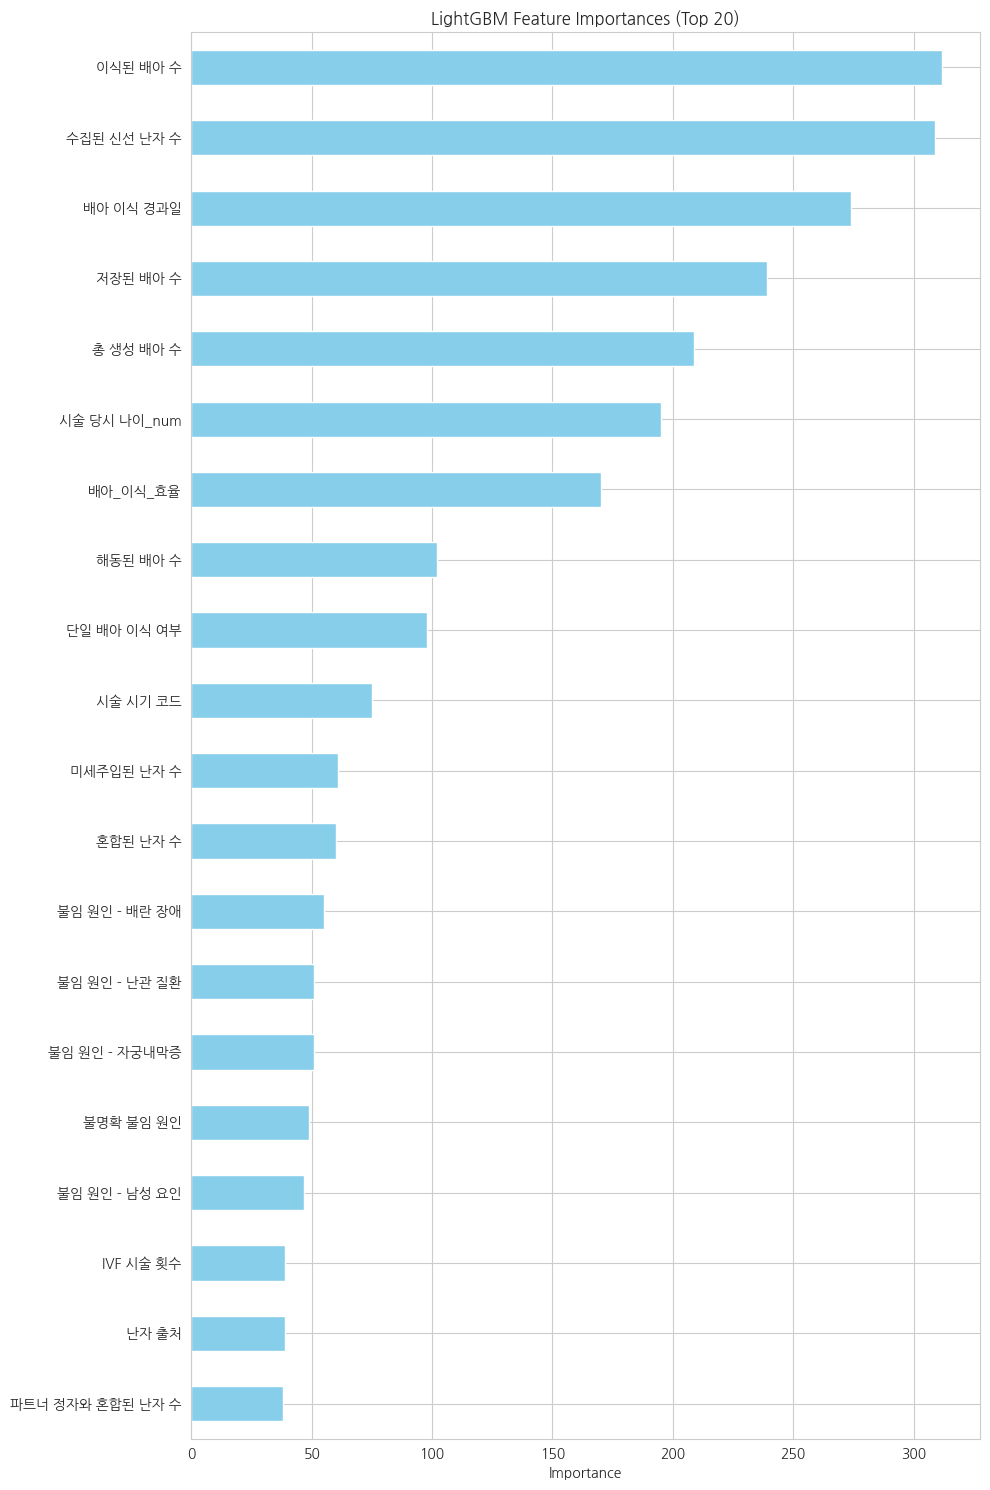

In [19]:
!pip install koreanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib # 한글 폰트 설정 재적용

# 중요도가 높을 것으로 예상되는 변수들을 시각화
importances = pd.Series(lgbm_model.feature_importances_, index=X_train_full.columns)
plt.figure(figsize=(10, 15))
importances.sort_values().tail(20).plot(kind='barh', color='skyblue')
plt.title('LightGBM Feature Importances (Top 20)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [20]:
from lightgbm import LGBMClassifier

# 소수 클래스 비율 계산
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 가중치를 적용한 모델 (SMOTE 대신 원본 X_train 사용)
lgbm_weighted = LGBMClassifier(
    n_estimators=100,
    scale_pos_weight=ratio, # 소수 클래스에 더 큰 비중 부여
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_weighted.fit(X_train, y_train)

y_pred_w = lgbm_weighted.predict(X_val)
y_prob_w = lgbm_weighted.predict_proba(X_val)[:, 1]

print("[가중치 조절 LightGBM 성능 평가]")
print(f"Accuracy: {accuracy_score(y_val, y_pred_w):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob_w):.4f}")
print("\n[Classification Report]")
print(classification_report(y_val, y_pred_w))

[가중치 조절 LightGBM 성능 평가]
Accuracy: 0.6149
ROC-AUC: 0.7317

[Classification Report]
              precision    recall  f1-score   support

           0       0.88      0.56      0.68     38025
           1       0.38      0.78      0.51     13246

    accuracy                           0.61     51271
   macro avg       0.63      0.67      0.60     51271
weighted avg       0.75      0.61      0.64     51271



In [21]:
!pip install optuna > /dev/null

In [22]:
import optuna
from lightgbm import LGBMClassifier

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': ratio,
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }

    model = LGBMClassifier(**param)
    model.fit(X_train, y_train)

    preds = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds)
    return auc

# 최적화 실행
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20) # 시간 관계상 20회 시도

print("Best trial:")
trial = study.best_trial
print(f"  Value: {trial.value:.4f}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2026-04-29 01:07:57,312] A new study created in memory with name: no-name-b2fe304d-89b5-4fad-867b-1e0bb7d09a9b
[I 2026-04-29 01:09:06,293] Trial 0 finished with value: 0.730525567715082 and parameters: {'n_estimators': 453, 'learning_rate': 0.06150667891091046, 'max_depth': 10, 'num_leaves': 41, 'subsample': 0.6185115505359936, 'colsample_bytree': 0.9340440065363664}. Best is trial 0 with value: 0.730525567715082.
[I 2026-04-29 01:09:18,980] Trial 1 finished with value: 0.7220449228442352 and parameters: {'n_estimators': 317, 'learning_rate': 0.19476232653224712, 'max_depth': 12, 'num_leaves': 50, 'subsample': 0.6126238610692185, 'colsample_bytree': 0.6449067802101127}. Best is trial 0 with value: 0.730525567715082.
[I 2026-04-29 01:09:45,117] Trial 2 finished with value: 0.7317523884004331 and parameters: {'n_estimators': 500, 'learning_rate': 0.015019529708128625, 'max_depth': 14, 'num_leaves': 90, 'subsample': 0.9799558150239479, 'colsample_bytree': 0.9754643182465177}. Best is t

Best trial:
  Value: 0.7319
  Params: 
    n_estimators: 287
    learning_rate: 0.027008068296432992
    max_depth: 9
    num_leaves: 43
    subsample: 0.7869319693063329
    colsample_bytree: 0.9447778606972331


In [23]:
# 최적의 파라미터로 최종 모델 설정
best_params = study.best_trial.params
best_params['scale_pos_weight'] = ratio
best_params['random_state'] = 42
best_params['n_jobs'] = -1
best_params['verbose'] = -1

final_lgbm_model = LGBMClassifier(**best_params)

# 성능 검증을 위해 사용했던 X_train으로 먼저 학습 후 결과를 확인합니다.
final_lgbm_model.fit(X_train, y_train)

# 테스트 데이터 예측 확률 계산
# submission.csv 형식에 맞춰 ID와 probability 컬럼을 구성합니다.
test_probabilities = final_lgbm_model.predict_proba(X_test_full)[:, 1]

# 제출 파일 생성
submission = pd.read_csv('sample_submission.csv')
submission['probability'] = test_probabilities
submission.to_csv('final_submission.csv', index=False)

print("### 최종 제출 파일 생성 완료 (final_submission.csv) ###")
display(submission.head())

# 검증 데이터 성능 재확인
y_val_pred_final = final_lgbm_model.predict(X_val)
y_val_prob_final = final_lgbm_model.predict_proba(X_val)[:, 1]
print("\n[최종 모델 검증 성능]")
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_prob_final):.4f}")
print(classification_report(y_val, y_val_pred_final))

### 최종 제출 파일 생성 완료 (final_submission.csv) ###


,ID,probability
0,TEST_00000,0.002676
1,TEST_00001,0.006701
2,TEST_00002,0.382555
3,TEST_00003,0.366654
4,TEST_00004,0.731373



[최종 모델 검증 성능]
ROC-AUC: 0.7319
              precision    recall  f1-score   support

           0       0.88      0.56      0.68     38025
           1       0.38      0.77      0.51     13246

    accuracy                           0.62     51271
   macro avg       0.63      0.67      0.60     51271
weighted avg       0.75      0.62      0.64     51271



In [24]:
!pip install catboost > /dev/null

In [25]:
from catboost import CatBoostClassifier

# CatBoost 모델 설정 및 학습
# scale_pos_weight를 통해 불균형 처리 적용
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
    scale_pos_weight=ratio
)

cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)

# 각 모델의 예측 확률 추출
lgbm_prob = final_lgbm_model.predict_proba(X_val)[:, 1]
cat_prob = cat_model.predict_proba(X_val)[:, 1]

# 가중 평균 앙상블 (LGBM 0.6 : CatBoost 0.4)
ensemble_prob = (lgbm_prob * 0.6) + (cat_prob * 0.4)
ensemble_pred = (ensemble_prob > 0.5).astype(int)

print("\n[Ensemble (LGBM + CatBoost) 성능 평가]")
print(f"ROC-AUC: {roc_auc_score(y_val, ensemble_prob):.4f}")
print(f"Accuracy: {accuracy_score(y_val, ensemble_pred):.4f}")
print("\n[Classification Report]")
print(classification_report(y_val, ensemble_pred))

0:	test: 0.7091102	best: 0.7091102 (0)	total: 389ms	remaining: 3m 14s
100:	test: 0.7294001	best: 0.7294001 (100)	total: 36.4s	remaining: 2m 23s
200:	test: 0.7311117	best: 0.7311117 (200)	total: 54.2s	remaining: 1m 20s
300:	test: 0.7318466	best: 0.7318610 (295)	total: 1m 2s	remaining: 41.5s
400:	test: 0.7321188	best: 0.7321188 (400)	total: 1m 13s	remaining: 18.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.73219385
bestIteration = 419

Shrink model to first 420 iterations.

[Ensemble (LGBM + CatBoost) 성능 평가]
ROC-AUC: 0.7324
Accuracy: 0.6167

[Classification Report]
              precision    recall  f1-score   support

           0       0.88      0.56      0.69     38025
           1       0.38      0.77      0.51     13246

    accuracy                           0.62     51271
   macro avg       0.63      0.67      0.60     51271
weighted avg       0.75      0.62      0.64     51271

